In [1]:
import os
import pickle
import numpy as np

import sys
sys.path.insert(0, '../../')  # folder containing src/

def sort_nested_dict(d):
    if not isinstance(d, dict):
        return d
    return {
        k: sort_nested_dict(v)
        for k, v in sorted(d.items())
    }


def load_iter_data(root_dir: str, pickle_filename: str = "data.pkl", verbose=False):

    list_dict_data = {}

    for i, (dirpath, dirnames, filenames) in enumerate(os.walk(root_dir)):
        if verbose:
            print(f"{i}: {dirpath}")
        if pickle_filename in filenames:

            # load pickle results
            pickle_path = os.path.join(dirpath, pickle_filename)
            try:
                with open(pickle_path, 'rb') as f:
                    results = pickle.load(f)
            except Exception as e:
                print(f"Error loading {pickle_path}: {e}")

            key = int(dirpath.split("/")[-1].split("_")[-1])
            list_dict_data[key] = results


    print(f"num_iter: {len(list_dict_data)}")

    return list_dict_data



def extract_data(list_dict_data, key: str):

    data_key = []
    for d in list_dict_data.values():
        data_key.append(d[key])

    return np.array(data_key)



In [2]:
root_dir = "data/20260805_063333"
root_dir = "data/20260806_010959"

dict_data = load_iter_data(root_dir)
dict_data = sort_nested_dict(dict_data)

num_iter = len(dict_data)

E_reached = np.zeros(num_iter, dtype=int)
E_target = np.zeros(num_iter, dtype=int)

for i in range(num_iter):
    E_reached[i] = int(np.min(dict_data[i]['E_disc']))
    E_target[i] = int(dict_data[i]['target'][-1])

E_zz_diff = E_reached - E_target

print(f'\n# solved: {np.sum(E_zz_diff == 0)}/{num_iter}')
print(f'E_zz diffs: {E_zz_diff}')

num_iter: 10

# solved: 3/10
E_zz diffs: [ 4 24  8  8  0 28  4  0  8  0]


array([ 0.,  0.,  0.,  8.,  8., 28., 16., 20., 16.,  4.])

In [3]:
# root_dir = "data/20260729_030846_loop" # eps_theta = 0.001 *pi/2
root_dir = "data/20260728_082514_loop" # eps_theta = 0.01 * pi/2
# root_dir = "data/20260729_014038_loop" # eps_theta = 0.1 *pi/2
# root_dir = "data/20260729_045542_loop" # eps_theta = 0.01 *pi/2, BD = 25
#root_dir = "data/20260729_052658_loop" # eps_theta = 0.01 *pi/2, BD = 1 (classical)

dict_data = load_iter_data(root_dir)
dict_data = sort_nested_dict(dict_data)

num_iter: 200


In [4]:
Es = extract_data(dict_data, key='E')
E_disc = extract_data(dict_data, key='E_disc')
expect_Zs = extract_data(dict_data, key='Z_expect')
entropy_penalty = extract_data(dict_data, key='entropy_penalty')
corrs = extract_data(dict_data, key='correlation')

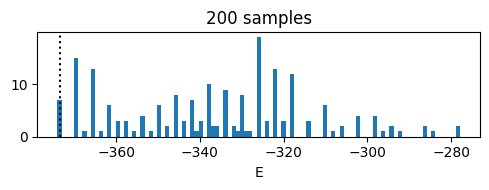

In [5]:
import matplotlib.pyplot as plt

target_E = -374

min_E = int(np.min(Es[:,-1]))
max_E = int(np.max(Es[:,-1]))

plt.figure(figsize=(5,2))
plt.hist(Es[:,-1], bins=max_E-min_E + 1)
plt.axvline(target_E + 0.5, color="k", linestyle=":")
plt.xlabel('E')
plt.title('200 samples')
plt.tight_layout()
plt.show()

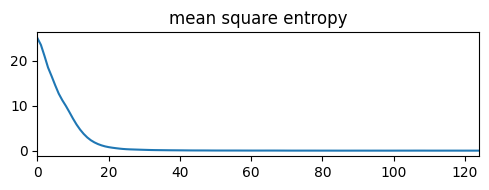

In [6]:
max_it = 125

plt.figure(figsize=(5,2))
plt.plot(np.mean(entropy_penalty[:,:max_it], axis=0))
plt.title('mean square entropy')
plt.xlim([0,max_it-1])
plt.tight_layout()
plt.show()

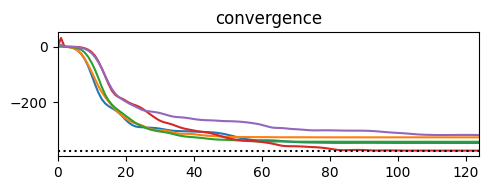

In [7]:
target_E = -374

max_it = 125

plt.figure(figsize=(5,2))
plt.title('convergence')
plt.plot(Es[0:-1:40,:max_it].T)
#plt.plot(E_disc[0:-1:40].T, linestyle=":")
plt.axhline(target_E, color="k", linestyle=":")
plt.xlim([0,max_it-1])
plt.tight_layout()
plt.show()

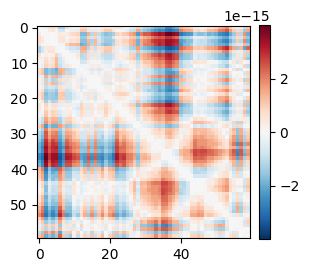

In [10]:
data = np.real(corrs[0,-1])
vmax = np.abs(data).max()

fig, ax = plt.subplots(figsize=(3, 3))
im = ax.imshow(data, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04) 

In [21]:
[len(dat['E']) for dat in list_dict_data]

[20,
 20,
 19,
 20,
 20,
 19,
 19,
 19,
 20,
 200,
 19,
 200,
 19,
 19,
 20,
 19,
 20,
 20,
 20,
 20,
 19,
 200,
 19,
 200,
 20,
 20,
 200,
 200,
 19,
 200,
 200,
 19,
 200,
 20,
 19,
 19,
 20,
 19,
 20,
 19,
 20,
 20,
 20,
 19,
 20,
 20,
 20,
 20,
 19,
 19,
 20,
 20,
 200,
 19,
 200,
 200,
 200,
 20,
 19,
 20,
 20,
 20,
 200,
 20,
 19,
 20,
 19,
 200,
 19,
 20,
 200,
 19,
 20,
 19,
 200,
 200,
 200,
 200,
 19,
 19,
 19,
 20,
 20,
 19,
 20,
 19,
 19,
 20,
 200,
 20,
 19,
 20,
 19,
 19,
 20,
 200,
 20,
 200,
 19,
 20,
 19,
 19,
 19,
 19,
 200,
 200,
 20,
 19,
 19,
 20,
 20,
 19,
 19,
 200,
 19,
 20,
 19,
 19,
 20,
 19,
 19,
 20,
 20,
 19,
 200,
 200,
 20,
 19,
 19,
 20,
 20,
 20,
 200,
 20,
 19,
 200,
 19,
 20,
 200,
 19,
 20,
 19,
 19,
 200,
 20,
 19,
 19,
 200,
 200,
 20,
 19,
 20,
 19,
 19,
 20,
 20,
 20,
 200,
 20,
 20,
 20,
 19,
 19,
 19,
 20,
 200,
 20,
 200,
 20,
 20,
 200,
 20,
 20,
 19,
 19,
 20,
 20,
 19,
 200,
 19,
 20,
 20,
 200,
 20,
 20,
 20,
 20,
 19,
 20,
 20,
 19,
 19,
